In [6]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to c:\users\janba\appdata\local\temp\pip-req-build-yosazfw4
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\janba\AppData\Local\Temp\pip-req-build-yosazfw4'

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [8]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [5]:
for m in clip.available_models():
    model, preprocess = clip.load(m, device=device)
    
    input_resolution = model.visual.input_resolution
    context_length = model.context_length
    vocab_size = model.vocab_size

    print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
    print("Input resolution:", input_resolution)
    print("Context length:", context_length)
    print("Vocab size:", vocab_size)

    n_params_vision = sum(p.numel() for p in model.visual.parameters())
    n_params_text = sum(p.numel() for p in model.transformer.parameters())
    image = preprocess(Image.open("../datasets/image_sample/kat.png")).unsqueeze(0).to(device)
    image_features = model.encode_image(image)
    print(f"Model: {m}, #vision parameters: {n_params_vision:,}, #text parameters: {n_params_text:,}, embedding dimension: {image_features.shape[1]}")
    del model, preprocess, image, image_features

100%|███████████████████████████████████████| 244M/244M [02:02<00:00, 2.08MiB/s]


Model parameters: 102,007,137
Input resolution: 224
Context length: 77
Vocab size: 49408


c:\Users\janba\anaconda3\envs\workspace_jan\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Model: RN50, #vision parameters: 38,316,896, #text parameters: 37,828,608, embedding dimension: 1024


100%|███████████████████████████████████████| 278M/278M [02:16<00:00, 2.14MiB/s]


...

Model parameters: 149,620,737
Input resolution: 224
Context length: 77
Vocab size: 49408
Model: ViT-B/16, #vision parameters: 86,192,640, #text parameters: 37,828,608, embedding dimension: 512


100%|███████████████████████████████████████| 890M/890M [05:41<00:00, 2.73MiB/s]


Model parameters: 427,616,513
Input resolution: 224
Context length: 77
Vocab size: 49408
Model: ViT-L/14, #vision parameters: 303,966,208, #text parameters: 85,054,464, embedding dimension: 768


100%|███████████████████████████████████████| 891M/891M [05:42<00:00, 2.73MiB/s]


Model parameters: 427,944,193
Input resolution: 336
Context length: 77
Vocab size: 49408
Model: ViT-L/14@336px, #vision parameters: 304,293,888, #text parameters: 85,054,464, embedding dimension: 768


In [2]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [3]:
model, preprocess = clip.load('RN101', device=device)

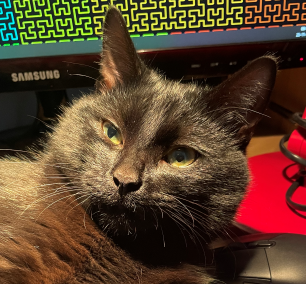

In [116]:
target_img = Image.open("../datasets/image_sample/kat.png")
target_img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


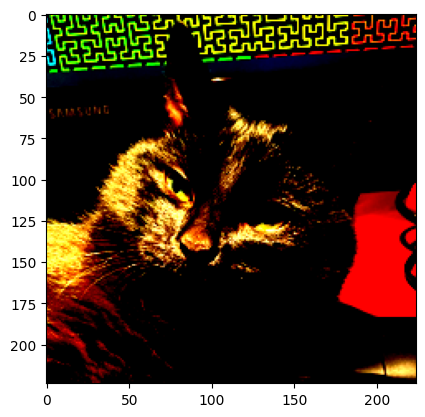

In [117]:
image = preprocess(target_img).unsqueeze(0).to(device)

plt.imshow(image.cpu().squeeze().permute(1, 2, 0).numpy())

In [118]:
image_features = model.encode_image(image)

image_features.shape

torch.Size([1, 512])

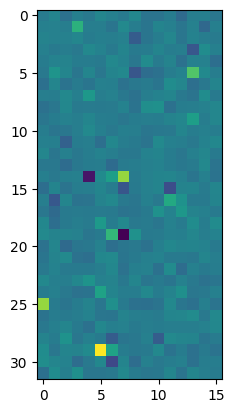

In [119]:
plt.imshow(image_features.detach().cpu().numpy().reshape(32, -1))

In [170]:
positive = [
    'image of a cat',
    'image of a kitten',
    'image of a black cat',
    'image of a mammal',
]

negative = [
    'image of a dog',
    'image of a turtle',
    'image of a human',
    'image of a bird',
    'image of a reptile',
]

positive_emb = model.encode_text(clip.tokenize(positive).to(device))
negative_emb = model.encode_text(clip.tokenize(positive).to(device))

In [185]:
losses = []

x = torch.randn(1, 3, 224, 224, requires_grad=True).to(device)
x.retain_grad()

0 0.9423828125
1 0.9423828125
2 0.94189453125
3 0.94287109375
4 0.9404296875
5 0.9365234375
6 0.9423828125
7 0.9423828125
8 0.93994140625
9 0.93896484375
10 0.9384765625
11 0.9404296875
12 0.93896484375
13 0.94140625
14 0.943359375
15 0.9423828125
16 0.943359375
17 0.94287109375
18 0.943359375
19 0.9443359375
20 0.94091796875
21 0.94287109375
22 0.94287109375
23 0.943359375
24 0.94091796875
25 0.93994140625
26 0.94140625
27 0.94140625
28 0.94140625
29 0.94140625
30 0.94189453125
31 0.94384765625
32 0.9453125
33 0.943359375
34 0.9443359375
35 0.943359375
36 0.94287109375
37 0.94287109375
38 0.94384765625
39 0.9423828125
40 0.94287109375
41 0.9443359375
42 0.94287109375
43 0.94287109375
44 0.94384765625
45 0.94189453125
46 0.94287109375
47 0.9423828125
48 0.9443359375
49 0.94482421875
50 0.9443359375
51 0.9423828125
52 0.94140625
53 0.943359375
54 0.9423828125
55 0.94140625
56 0.9443359375
57 0.9443359375
58 0.9443359375
59 0.94384765625
60 0.94140625
61 0.94384765625
62 0.9423828125
63 

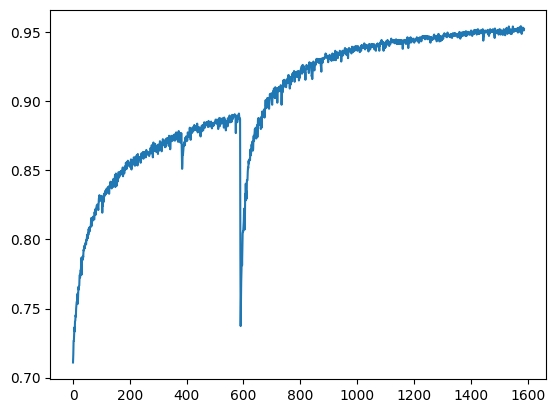

In [ ]:
epochs = 500
lr = 0.01

model.train()
for i in range(epochs):

    pred = model.encode_image(x)

    # loss = torch.sum((pred - image_features)**2)
    sim = torch.cosine_similarity(pred, image_features) + torch.cosine_similarity(pred, positive_emb).mean() - torch.cosine_similarity(pred, negative_emb).mean()

    sim.backward(retain_graph=True)
    losses.append(sim.item())
    print(i, sim.item())

    x += lr * x.grad

    x.grad.zero_()

plt.plot(losses)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.725355..5.1283264].


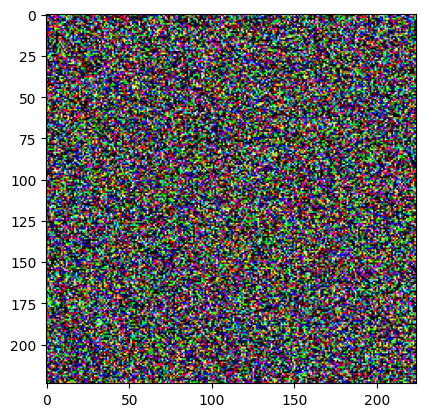

In [193]:
plt.imshow(x.detach().cpu().squeeze().permute(1, 2, 0).numpy())

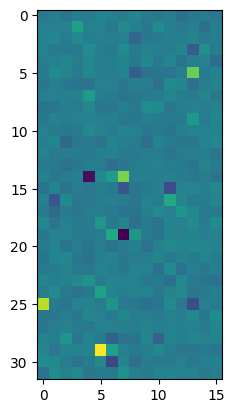

In [194]:
plt.imshow(pred.detach().cpu().numpy().reshape(32, -1))